# Assignment: Image Segmentation with Different CNN Architectures

Train and compare at least two different CNN-based segmentation models (Simple FCN and a small U-Net-like model) on an image+mask dataset, and visualize their results.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
train_dataset_path = '/content/drive/MyDrive/AI_Vision_Extract_Nov25/data/COCO2017_SAMPLE/train2017',
mask_train_dataset_path = '/content/drive/MyDrive/AI_Vision_Extract_Nov25/data/COCO2017_SAMPLE/mask_train2017'

In [6]:
# Run in Colab
!pip install -q tensorflow

import os
from glob import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, Model
print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


In [7]:
from google.colab import drive
drive.mount('/content/drive')

# EDIT these to your folders
IMG_DIR = "/content/drive/MyDrive/AI_Vision_Extract_Nov25/data/COCO2017_SAMPLE/train2017"
MASK_DIR = "/content/drive/MyDrive/AI_Vision_Extract_Nov25/data/COCO2017_SAMPLE/mask_train2017"

print("Images exist?", os.path.isdir(IMG_DIR))
print("Masks  exist?", os.path.isdir(MASK_DIR))

# quick listing to verify filenames
img_files = sorted([os.path.basename(p) for p in glob(os.path.join(IMG_DIR, "*")) if p.lower().endswith((".png",".jpg",".jpeg"))])
mask_files = sorted([os.path.basename(p) for p in glob(os.path.join(MASK_DIR, "*")) if p.lower().endswith((".png",".jpg",".jpeg"))])
print("Sample image files:", img_files[:5])
print("Sample mask files:", mask_files[:5])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Images exist? True
Masks  exist? True
Sample image files: ['000000000036.jpg', '000000000073.jpg', '000000000089.jpg', '000000000109.jpg', '000000000196.jpg']
Sample mask files: ['000000000009_mask.png', '000000000025_mask.png', '000000000030_mask.png', '000000000034_mask.png', '000000000036_mask.png']


In [8]:
IMG_SIZE = 128

def load_image(path, size=IMG_SIZE):
    img = Image.open(path).convert("RGB").resize((size,size))
    arr = np.array(img)/255.0
    return arr.astype(np.float32)

def load_mask(path, size=IMG_SIZE):
    m = Image.open(path).convert("L").resize((size,size))
    arr = np.array(m)/255.0
    arr = (arr > 0.5).astype(np.float32)   # binary mask
    arr = np.expand_dims(arr, -1)          # shape (H,W,1)
    return arr.astype(np.float32)


In [13]:
from glob import glob
import os
import random

# Load image and mask paths
img_paths = sorted(glob(os.path.join(IMG_DIR, "*")))
mask_paths = sorted(glob(os.path.join(MASK_DIR, "*")))

print("Images found:", len(img_paths))
print("Masks found:", len(mask_paths))

# Pair by index (NOT filename)
n = min(len(img_paths), len(mask_paths))
pairs = list(zip(img_paths[:n], mask_paths[:n]))

print("Paired files count:", len(pairs))

# Train/Val split
random.shuffle(pairs)
split = int(0.8 * len(pairs))
train_pairs = pairs[:split]
val_pairs = pairs[split:]

print("Train pairs:", len(train_pairs))
print("Val pairs:", len(val_pairs))


Images found: 11828
Masks found: 38102
Paired files count: 11828
Train pairs: 9462
Val pairs: 2366


In [14]:
def gen(pairs):
    for imgp, maskp in pairs:
        yield load_image(imgp), load_mask(maskp)

def make_dataset(pairs, batch=8, shuffle=False):
    ds = tf.data.Dataset.from_generator(
        lambda: gen(pairs),
        output_signature=(
            tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 1), dtype=tf.float32),
        )
    )
    if shuffle:
        ds = ds.shuffle(200)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

batch_size = 8
train_ds = make_dataset(train_pairs, batch=batch_size, shuffle=True)
val_ds   = make_dataset(val_pairs, batch=batch_size, shuffle=False)

print("Datasets ready!")


Datasets ready!


In [15]:
def tiny_unet(input_shape=(IMG_SIZE,IMG_SIZE,3)):
    inputs = layers.Input(shape=input_shape)
    # encoder
    c1 = layers.Conv2D(16,3,padding='same', activation='relu')(inputs)
    p1 = layers.MaxPool2D()(c1)
    c2 = layers.Conv2D(32,3,padding='same', activation='relu')(p1)
    p2 = layers.MaxPool2D()(c2)
    # bottleneck
    b = layers.Conv2D(64,3,padding='same', activation='relu')(p2)
    # decoder
    u1 = layers.UpSampling2D()(b)
    u1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv2D(32,3,padding='same', activation='relu')(u1)
    u2 = layers.UpSampling2D()(c3)
    u2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv2D(16,3,padding='same', activation='relu')(u2)
    outputs = layers.Conv2D(1,1,activation='sigmoid')(c4)
    return Model(inputs, outputs)

model = tiny_unet()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_2[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     27,680 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_3[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 48)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │      6,928 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │         17 │ conv2d_4[0][0]    │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 58,209 (227.38 KB)

 Trainable params: 58,209 (227.38 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step


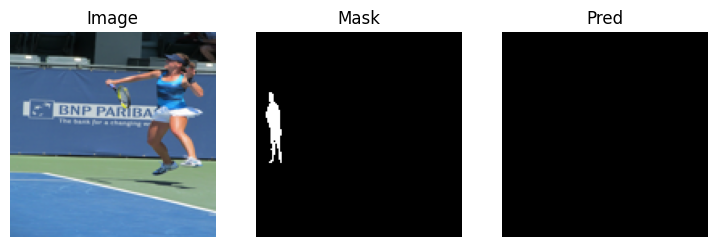

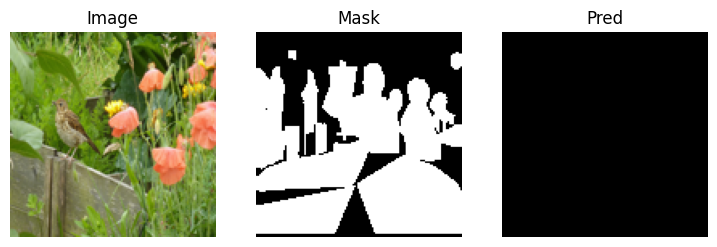

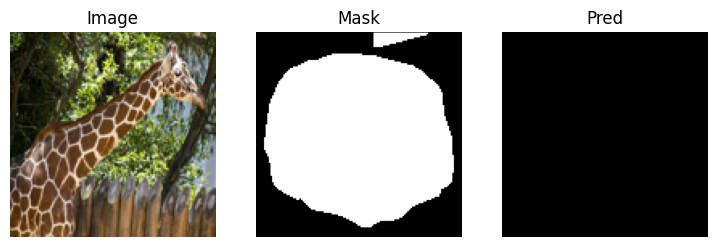

In [17]:
def show_some_predictions(ds, model, n=3):
    batch = next(iter(ds))
    imgs, masks = batch[0], batch[1]
    preds = model.predict(imgs)
    for i in range(min(n, imgs.shape[0])):
        plt.figure(figsize=(9,3))
        plt.subplot(1,3,1); plt.imshow(imgs[i]); plt.title("Image"); plt.axis('off')
        plt.subplot(1,3,2); plt.imshow(masks[i,:,:,0], cmap='gray'); plt.title("Mask"); plt.axis('off')
        plt.subplot(1,3,3); plt.imshow((preds[i,:,:,0]>0.5).astype(float), cmap='gray'); plt.title("Pred"); plt.axis('off')
        plt.show()

show_some_predictions(val_ds, model, n=3)
